<a href="https://colab.research.google.com/github/Shashank18ram/Data-Science/blob/main/ToyotaCorolla_MLR_Assignment7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiple Linear Regression Toyota Corolla Price Prediction
  EDA, preprocessing, 80/20 split, three regression models, coefficient interpretation, evaluation, Lasso, Ridge, multicollinearity/VIF, interview questions, and assumptions.

The  target as Toyota Corolla **Price** and lists Age, KM, FuelType, HP, Automatic, CC, Doors, Weight and Quarterly_Tax as attributes.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid")

DATA_PATH = "ToyotaCorolla - MLR.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())

Shape: (1436, 11)


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


## 1. Dataset Overview

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isna().sum().to_frame("count"))
print("\nDuplicate rows:", df.duplicated().sum())

Rows: 1436
Columns: 11

Columns:
['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']

Data types:


,dtype
Price,int64
Age_08_04,int64
KM,int64
Fuel_Type,object
HP,int64
Automatic,int64
cc,int64
Doors,int64
Cylinders,int64
Gears,int64



Missing values:


,count
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0



Duplicate rows: 1


## 2. Cleaning and Preprocessing

In [4]:
df_clean = df.drop_duplicates().copy()

target = "Price"
X = df_clean.drop(columns=target)
y = df_clean[target]

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

print("Numerical:", numeric_cols)
print("Categorical:", categorical_cols)
display(df_clean.describe(include="all").T)

Numerical: ['Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']
Categorical: ['Fuel_Type']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Price,"1,435.0000",NaN,NaN,NaN,"10,720.9157","3,608.7330","4,350.0000","8,450.0000","9,900.0000","11,950.0000","32,500.0000"
Age_08_04,"1,435.0000",NaN,NaN,NaN,55.9805,18.5633,1.0000,44.0000,61.0000,70.0000,80.0000
KM,"1,435.0000",NaN,NaN,NaN,"68,571.7826","37,491.0946",1.0000,"43,000.0000","63,451.0000","87,041.5000","243,000.0000"
Fuel_Type,1435,3,Petrol,1264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HP,"1,435.0000",NaN,NaN,NaN,101.4920,14.9814,69.0000,90.0000,110.0000,110.0000,192.0000
Automatic,"1,435.0000",NaN,NaN,NaN,0.0557,0.2295,0.0000,0.0000,0.0000,0.0000,1.0000
cc,"1,435.0000",NaN,NaN,NaN,"1,576.5610",424.3875,"1,300.0000","1,400.0000","1,600.0000","1,600.0000","16,000.0000"
Doors,"1,435.0000",NaN,NaN,NaN,4.0328,0.9527,2.0000,3.0000,4.0000,5.0000,5.0000
Cylinders,"1,435.0000",NaN,NaN,NaN,4.0000,0.0000,4.0000,4.0000,4.0000,4.0000,4.0000
Gears,"1,435.0000",NaN,NaN,NaN,5.0265,0.1886,3.0000,5.0000,5.0000,5.0000,6.0000


Missing numerical values are handled by median imputation and categorical values by most-frequent imputation. Categorical variables are one-hot encoded. Standardization is included in the preprocessing pipeline so Ridge and Lasso operate on comparable feature scales.

## 3. Exploratory Data Analysis

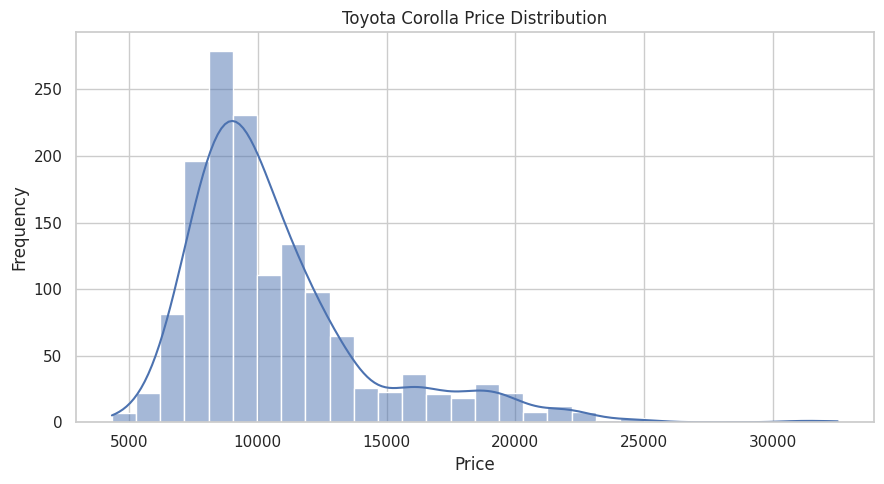

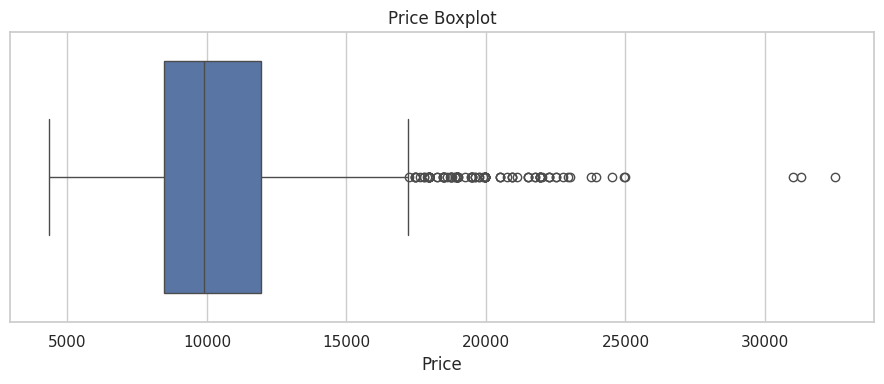

In [5]:
# Price distribution
plt.figure(figsize=(9,5))
sns.histplot(df_clean[target], kde=True, bins=30)
plt.title("Toyota Corolla Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
sns.boxplot(x=df_clean[target])
plt.title("Price Boxplot")
plt.tight_layout()
plt.show()

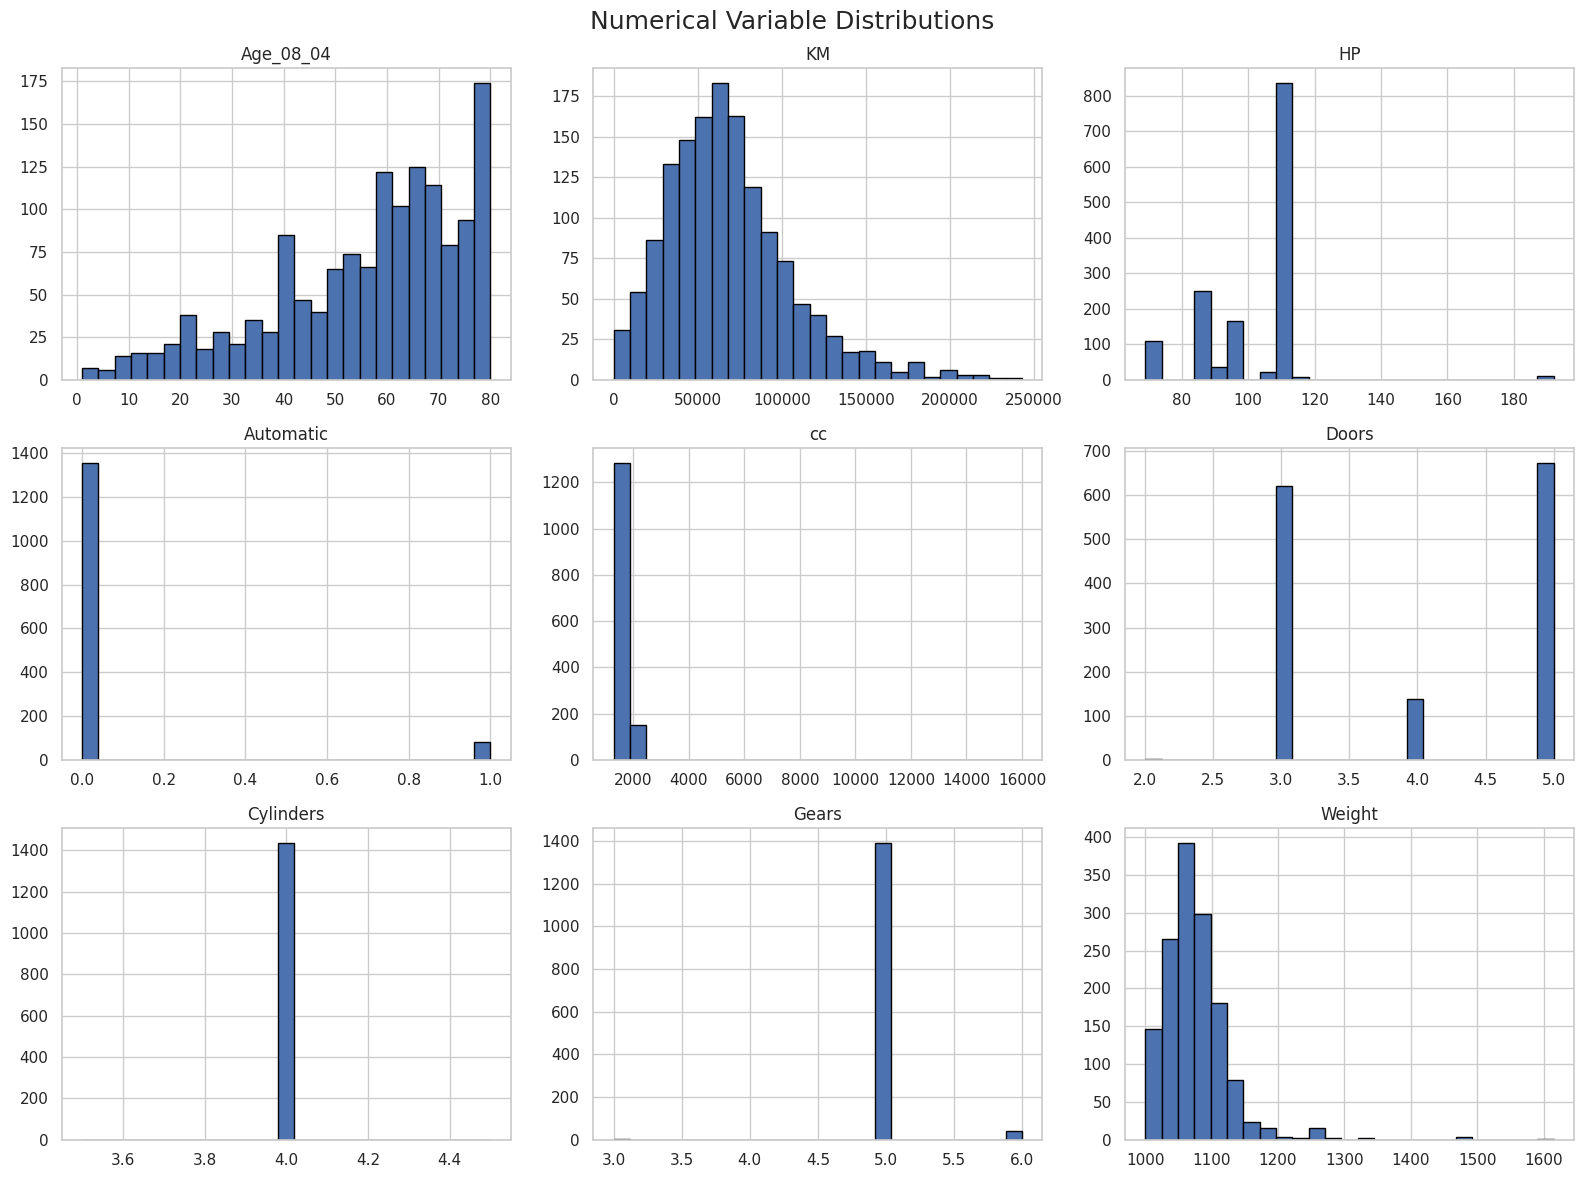

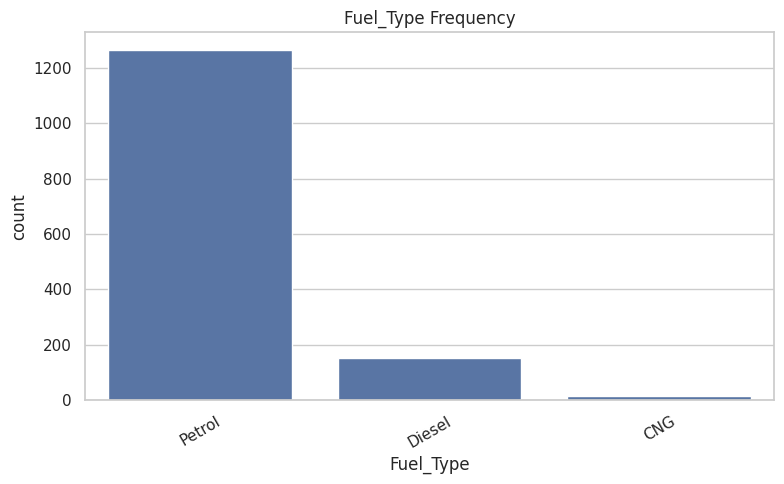

In [6]:
# Numerical distributions
if numeric_cols:
    df_clean[numeric_cols].hist(figsize=(16,12), bins=25, edgecolor="black")
    plt.suptitle("Numerical Variable Distributions", fontsize=18)
    plt.tight_layout()
    plt.show()

# Categorical distributions
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df_clean, x=col, order=df_clean[col].value_counts().index)
    plt.title(f"{col} Frequency")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

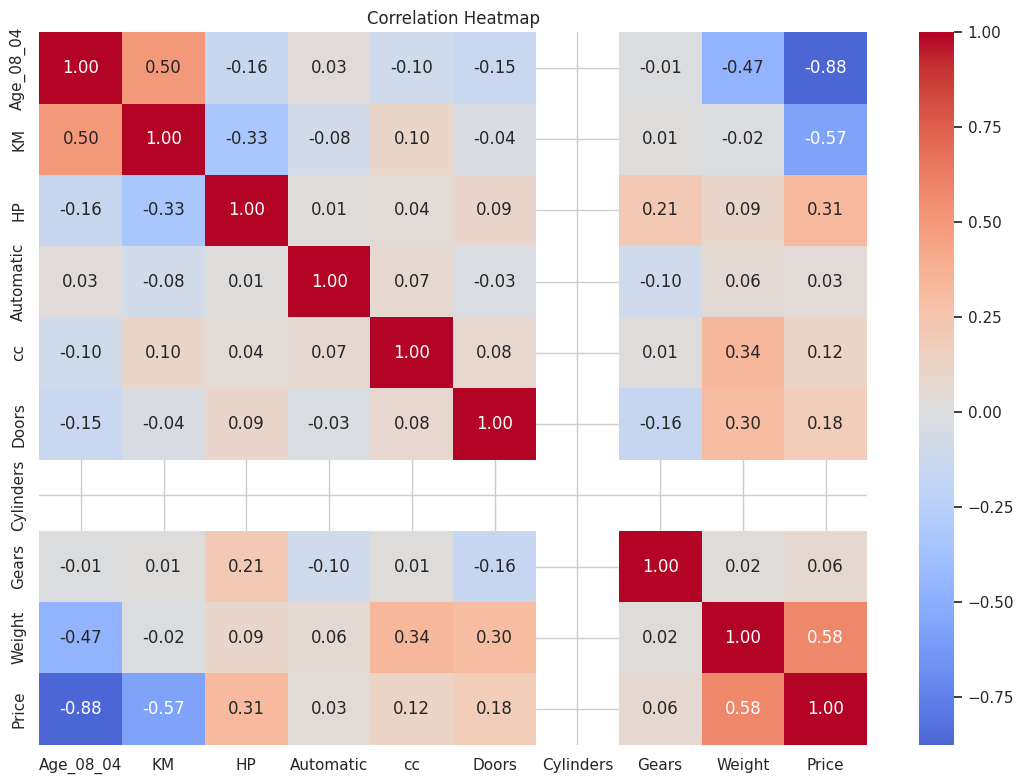

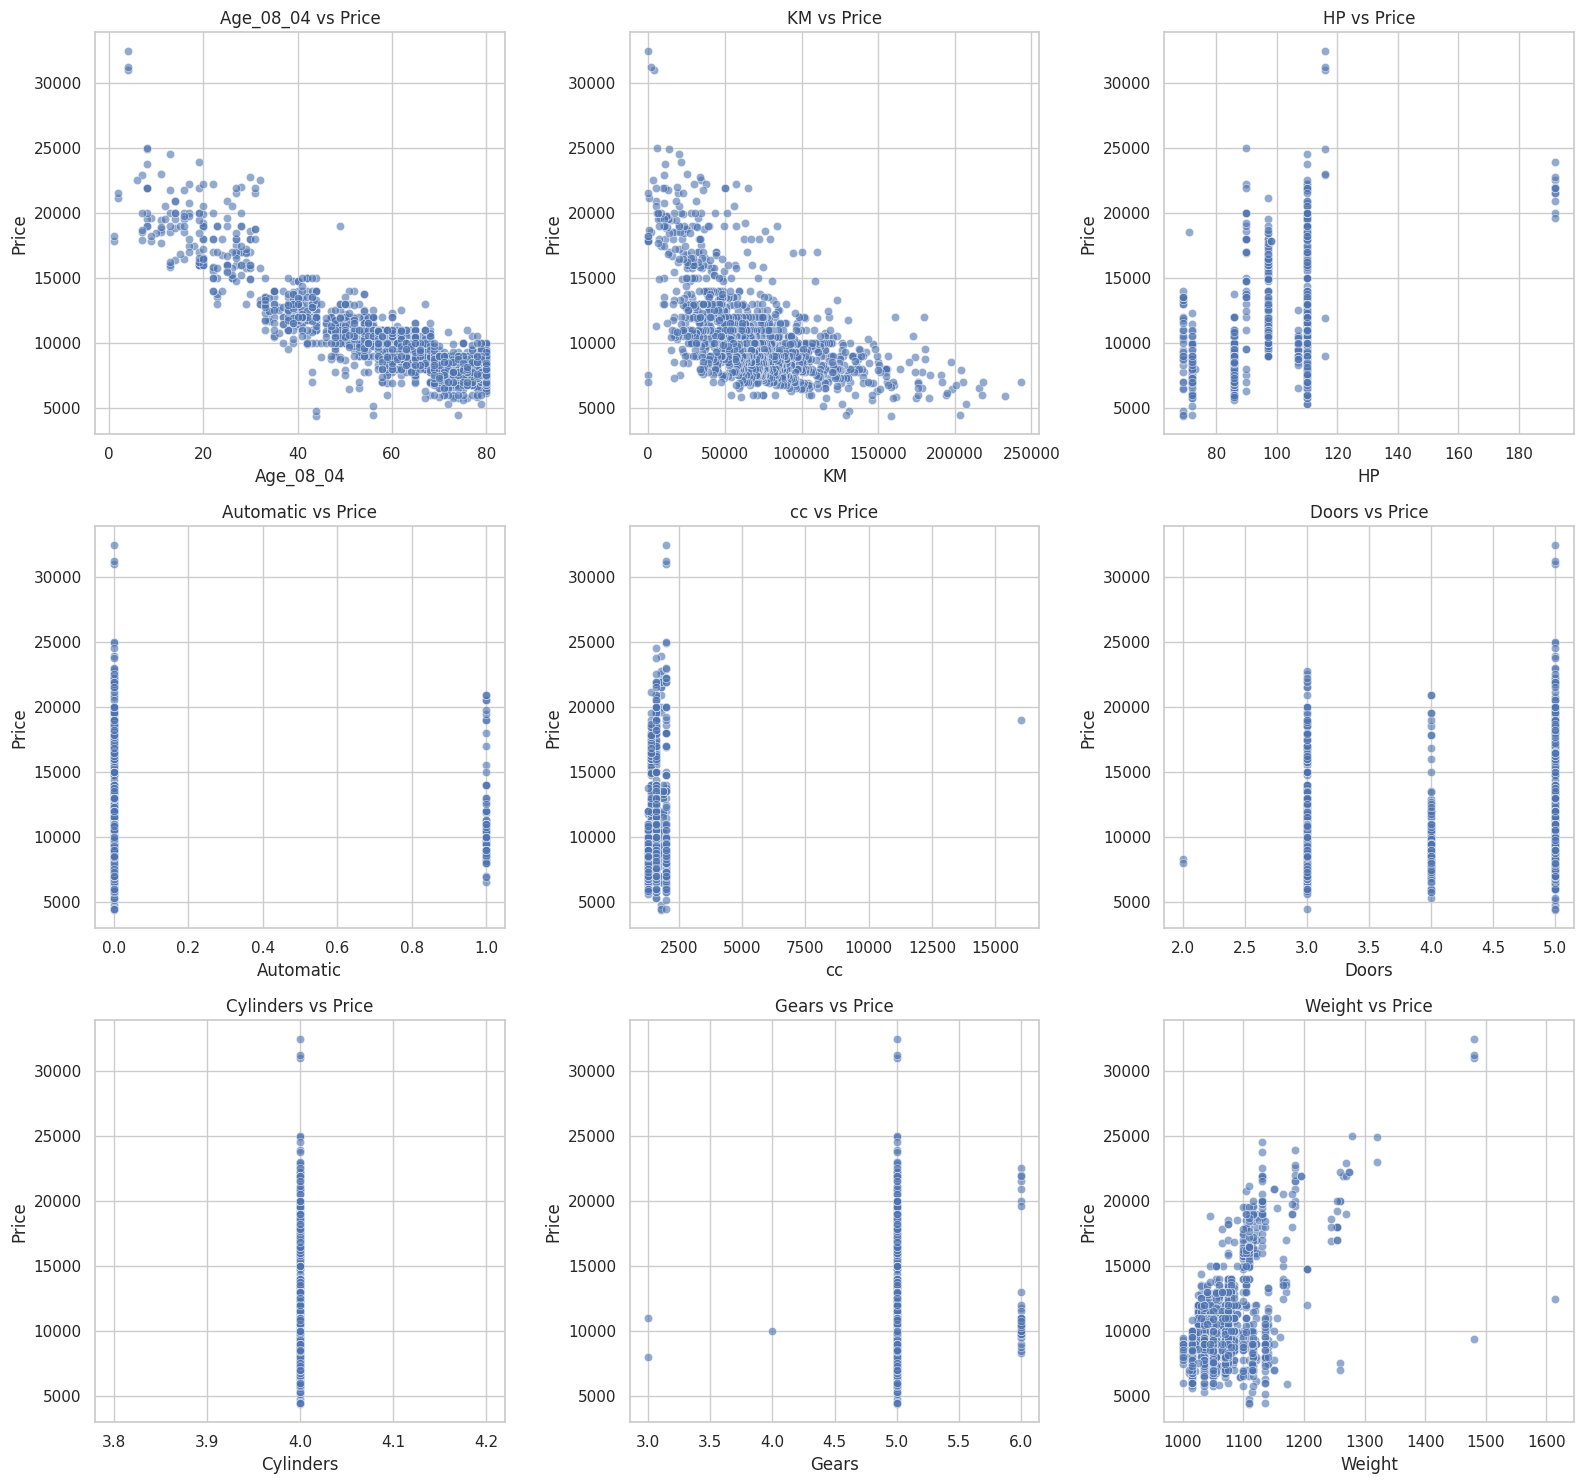

In [7]:
# Correlation heatmap
corr_cols = numeric_cols + [target]
plt.figure(figsize=(11,8))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter plots
n = len(numeric_cols)
cols = 3
rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(16,5*rows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, numeric_cols):
    sns.scatterplot(data=df_clean, x=col, y=target, alpha=.6, ax=ax)
    ax.set_title(f"{col} vs Price")
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Outlier Detection

In [8]:
outliers = []
for col in numeric_cols + [target]:
    q1, q3 = df_clean[col].quantile([.25,.75])
    iqr = q3-q1
    lo, hi = q1-1.5*iqr, q3+1.5*iqr
    count = ((df_clean[col]<lo)|(df_clean[col]>hi)).sum()
    outliers.append([col,q1,q3,iqr,lo,hi,int(count),round(count/len(df_clean)*100,2)])

outlier_df = pd.DataFrame(outliers, columns=[
    "Variable","Q1","Q3","IQR","Lower","Upper","Outlier Count","Outlier %"
])
display(outlier_df.sort_values("Outlier Count", ascending=False))

print("Outliers are flagged rather than automatically deleted because extreme vehicle prices or attributes may be legitimate observations.")

,Variable,Q1,Q3,IQR,Lower,Upper,Outlier Count,Outlier %
4,cc,"1,400.0000","1,600.0000",200.0000,"1,100.0000","1,900.0000",122,8.5000
9,Price,"8,450.0000","11,950.0000","3,500.0000","3,200.0000","17,200.0000",109,7.6000
3,Automatic,0.0000,0.0000,0.0000,0.0000,0.0000,80,5.5700
8,Weight,"1,040.0000","1,085.0000",45.0000,972.5000,"1,152.5000",65,4.5300
1,KM,"43,000.0000","87,041.5000","44,041.5000","-23,062.2500","153,103.7500",49,3.4100
7,Gears,5.0000,5.0000,0.0000,5.0000,5.0000,46,3.2100
2,HP,90.0000,110.0000,20.0000,60.0000,140.0000,11,0.7700
0,Age_08_04,44.0000,70.0000,26.0000,5.0000,109.0000,7,0.4900
5,Doors,3.0000,5.0000,2.0000,0.0000,8.0000,0,0.0000
6,Cylinders,4.0000,4.0000,0.0000,4.0000,4.0000,0,0.0000


Outliers are flagged rather than automatically deleted because extreme vehicle prices or attributes may be legitimate observations.


## 5. Train/Test Split

 80% training and 20% testing split has been asked.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1148, 10)
Testing : (287, 10)


## 6. Preprocessing Pipeline

In [10]:
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, numeric_cols),
    ("cat", cat_pipe, categorical_cols)
])

## 7. Model 1 — Baseline Multiple Linear Regression

In [11]:
model1 = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

## 8. Model 2 — Polynomial Multiple Regression

In [12]:
poly_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

poly_preprocessor = ColumnTransformer([
    ("num", poly_num_pipe, numeric_cols),
    ("cat", cat_pipe, categorical_cols)
])

model2 = Pipeline([
    ("preprocessor", poly_preprocessor),
    ("regressor", LinearRegression())
])
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)

## 9. Model 3 — Reduced Feature MLR

In [13]:
corr = df_clean[numeric_cols + [target]].corr()[target].drop(target).abs()
selected_numeric = corr.sort_values(ascending=False).head(min(5,len(corr))).index.tolist()
selected_features = selected_numeric + categorical_cols

print("Selected numerical features:", selected_numeric)

reduced_num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reduced_preprocessor = ColumnTransformer([
    ("num", reduced_num_pipe, selected_numeric),
    ("cat", cat_pipe, categorical_cols)
])

model3 = Pipeline([
    ("preprocessor", reduced_preprocessor),
    ("regressor", LinearRegression())
])
model3.fit(X_train[selected_features], y_train)
pred3 = model3.predict(X_test[selected_features])

Selected numerical features: ['Age_08_04', 'Weight', 'KM', 'HP', 'Doors']


## 10. Model Evaluation

Thevaluation on the testing dataset.

In [14]:
def metrics(name, actual, predicted):
    return {
        "Model": name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "R2": r2_score(actual, predicted)
    }

results = pd.DataFrame([
    metrics("Baseline MLR", y_test, pred1),
    metrics("Polynomial MLR", y_test, pred2),
    metrics("Reduced MLR", y_test, pred3)
])
display(results.sort_values("RMSE").reset_index(drop=True))

,Model,MAE,RMSE,R2
0,Baseline MLR,986.4967,"1,468.2058",0.8203
1,Reduced MLR,985.7710,"1,483.2535",0.8166
2,Polynomial MLR,971.7687,"1,769.4389",0.7390


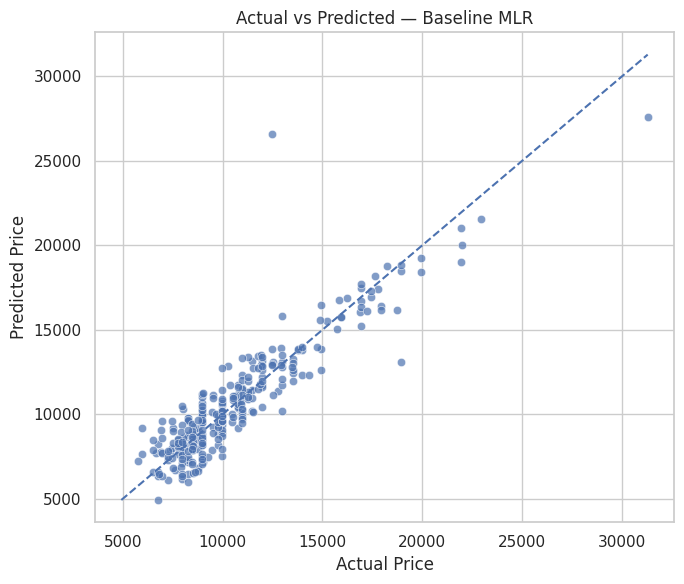

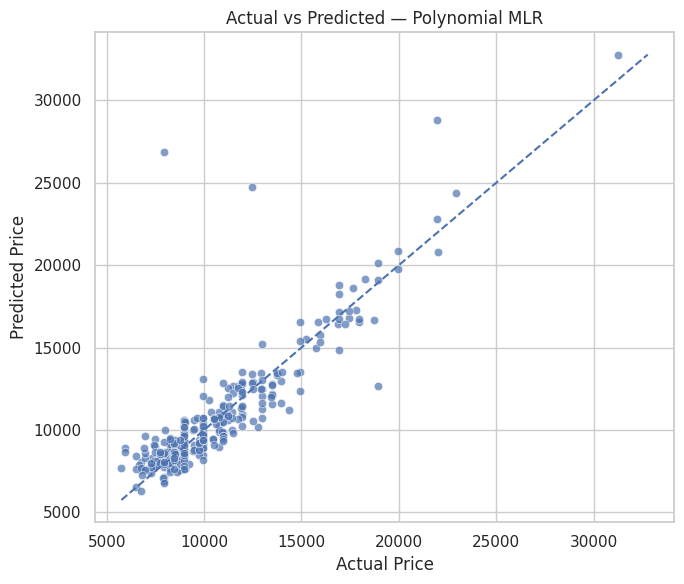

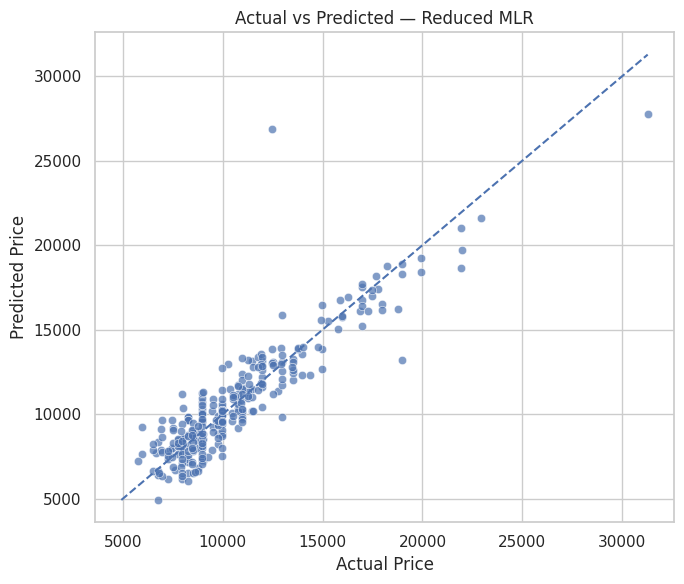

In [15]:
for name, pred in {
    "Baseline MLR": pred1,
    "Polynomial MLR": pred2,
    "Reduced MLR": pred3
}.items():
    plt.figure(figsize=(7,6))
    sns.scatterplot(x=y_test, y=pred, alpha=.7)
    lo=min(y_test.min(),pred.min()); hi=max(y_test.max(),pred.max())
    plt.plot([lo,hi],[lo,hi],"--")
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(f"Actual vs Predicted — {name}")
    plt.tight_layout()
    plt.show()

## 11. Coefficient Interpretation — Baseline MLR

In [16]:
feature_names = model1.named_steps["preprocessor"].get_feature_names_out()
coefs = model1.named_steps["regressor"].coef_

coef_df = pd.DataFrame({"Feature":feature_names, "Coefficient":coefs})
coef_df["Absolute Coefficient"] = coef_df["Coefficient"].abs()
display(coef_df.sort_values("Absolute Coefficient", ascending=False).head(20))

,Feature,Coefficient,Absolute Coefficient
0,num__Age_08_04,"-2,266.2029","2,266.2029"
8,num__Weight,"1,333.1833","1,333.1833"
10,cat__Fuel_Type_Petrol,"1,128.9331","1,128.9331"
1,num__KM,-604.3518,604.3518
9,cat__Fuel_Type_Diesel,-389.6838,389.6838
2,num__HP,241.6137,241.6137
5,num__Doors,-83.8103,83.8103
7,num__Gears,80.8742,80.8742
3,num__Automatic,59.8292,59.8292
4,num__cc,-21.9179,21.9179


Because numerical predictors are standardized, a numerical coefficient represents the expected change in Price for approximately one standard-deviation increase in that predictor, holding other variables constant. A categorical coefficient compares its encoded category with the reference category, holding other predictors constant. Positive coefficients increase predicted price; negative coefficients decrease it.

## 12. Lasso Regression

In [17]:
lasso = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=0.1, max_iter=10000))
])
lasso.fit(X_train, y_train)
pred_lasso = lasso.predict(X_test)
lasso_result = metrics("Lasso", y_test, pred_lasso)
display(pd.DataFrame([lasso_result]))

,Model,MAE,RMSE,R2
0,Lasso,986.4377,"1,467.8095",0.8204


## 13. Ridge Regression

In [18]:
ridge = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)
ridge_result = metrics("Ridge", y_test, pred_ridge)
display(pd.DataFrame([ridge_result]))

,Model,MAE,RMSE,R2
0,Ridge,986.8203,"1,466.0993",0.8208


## 14. Compare All Models

,Model,MAE,RMSE,R2
0,Ridge,986.8203,"1,466.0993",0.8208
1,Lasso,986.4377,"1,467.8095",0.8204
2,Baseline MLR,986.4967,"1,468.2058",0.8203
3,Reduced MLR,985.7710,"1,483.2535",0.8166
4,Polynomial MLR,971.7687,"1,769.4389",0.7390


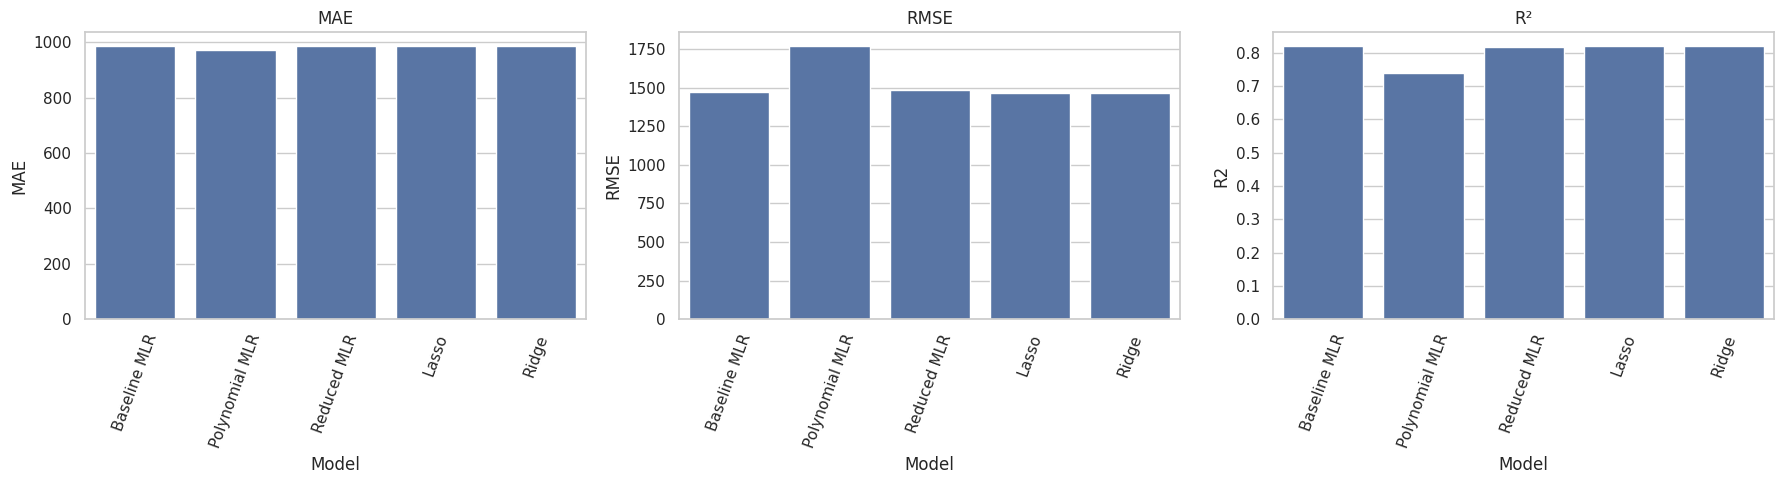

In [19]:
all_results = pd.DataFrame([
    metrics("Baseline MLR", y_test, pred1),
    metrics("Polynomial MLR", y_test, pred2),
    metrics("Reduced MLR", y_test, pred3),
    lasso_result,
    ridge_result
])
display(all_results.sort_values("RMSE").reset_index(drop=True))

fig, axes = plt.subplots(1,3,figsize=(18,5))
for ax, metric, title in zip(axes, ["MAE","RMSE","R2"], ["MAE","RMSE","R²"]):
    sns.barplot(data=all_results, x="Model", y=metric, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=70)
plt.tight_layout()
plt.show()

## 15. Residual Analysis

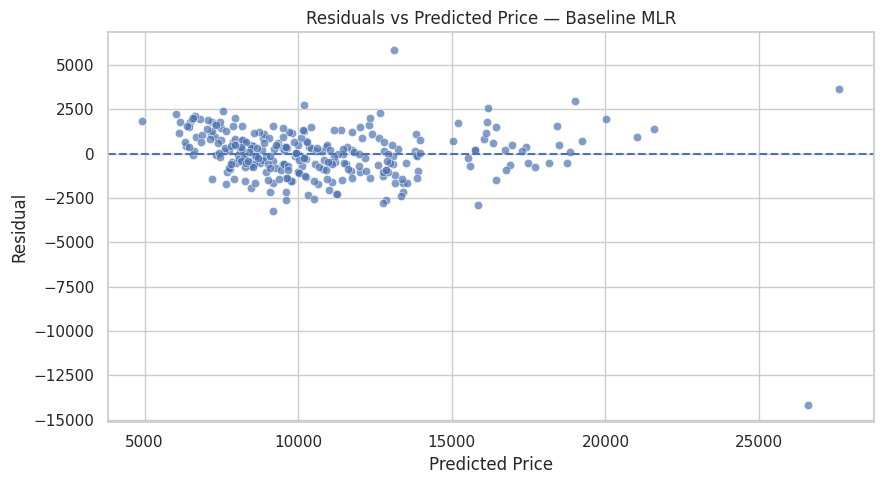

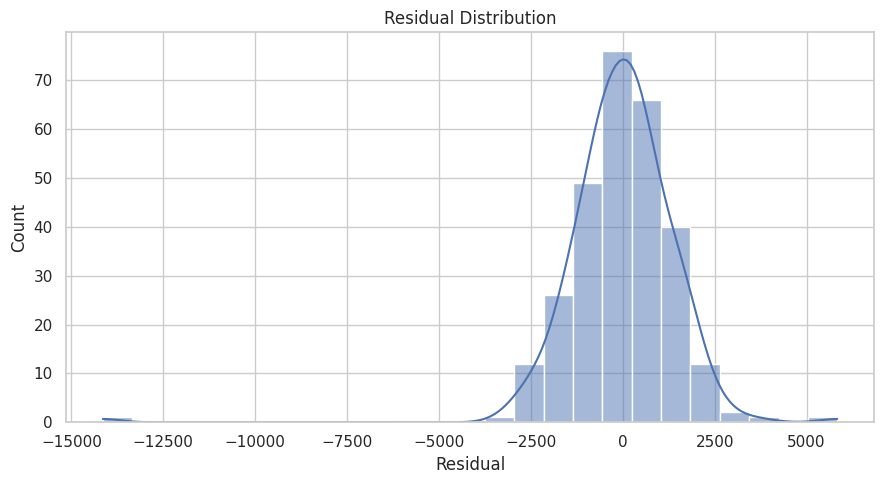

In [20]:
residuals = y_test - pred1

plt.figure(figsize=(9,5))
sns.scatterplot(x=pred1, y=residuals, alpha=.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Price — Baseline MLR")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
sns.histplot(residuals, kde=True, bins=25)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

## 16. Multicollinearity — VIF

In [23]:
# Select numerical variables
vif_data = df_clean[numeric_cols].copy()

# Handle missing values
vif_data = vif_data.fillna(vif_data.median())

# Add constant column
vif_const = sm.add_constant(vif_data, has_constant="add")

# Calculate VIF
vif_df = pd.DataFrame({
    "Feature": vif_data.columns,
    "VIF": [
        variance_inflation_factor(vif_const.values, i + 1)
        for i in range(len(vif_data.columns))
    ]
})

# Sort from highest to lowest VIF
vif_df = vif_df.sort_values("VIF", ascending=False)

display(vif_df)

,Feature,VIF
0,Age_08_04,1.9011
1,KM,1.6784
8,Weight,1.6593
2,HP,1.2173
5,Doors,1.1549
4,cc,1.1503
7,Gears,1.1093
3,Automatic,1.0480
6,Cylinders,0.0000


## 17. Interview Question 1 — Normalization and Standardization

**Normalization** rescales values to a fixed range, commonly 0–1:

`x' = (x - min(x)) / (max(x) - min(x))`

**Standardization** transforms values to approximately mean 0 and standard deviation 1:

`z = (x - mean(x)) / standard deviation(x)`

Both make variables comparable in scale. Standardization is particularly useful for Ridge and Lasso because their penalties depend on coefficient magnitudes.

## 18. Interview Question 2 Multicollinearity

 techniques include:
- Remove one of highly correlated predictors
- Feature selection
- Combine correlated variables when appropriate
- PCA
- Ridge regression
- Lasso regression
- VIF-based diagnosis



## 19. Regression Assumptions

1. **Linearity:** predictor relationships should be adequately represented by the model.
2. **Independence:** observations/errors should be independent.
3. **Homoscedasticity:** residual variance should be reasonably constant.
4. **Normality of residuals:** mainly important for classical inference.
5. **Limited problematic multicollinearity:** predictors should not be excessively redundant.
6. **No severe influential observations:** individual observations should not dominate the fitted model.



## 20. Final Conclusion

 Toyota Corolla multiple linear regression workflow: EDA, preprocessing, an 80/20 train-test split, three different MLR models, coefficient interpretation, test evaluation, Lasso, Ridge, multicollinearity analysis and assumptions.

The best model should be selected from the final results table. **Lower MAE/RMSE is better, while higher R square is better.** The numerical winner is calculated from the actual CSV when the notebook runs rather than being hard-coded.



In [24]:
best = all_results.loc[all_results["RMSE"].idxmin()]
print("Best model by test RMSE:", best["Model"])
print(f"MAE : {best['MAE']:.2f}")
print(f"RMSE: {best['RMSE']:.2f}")
print(f"R²  : {best['R2']:.4f}")

Best model by test RMSE: Ridge
MAE : 986.82
RMSE: 1466.10
R²  : 0.8208
